In [1]:
from occultence import *
#from nuance import utils

In [2]:
#len(t)

nr of measurements: 1906


(0.99, 1.015)

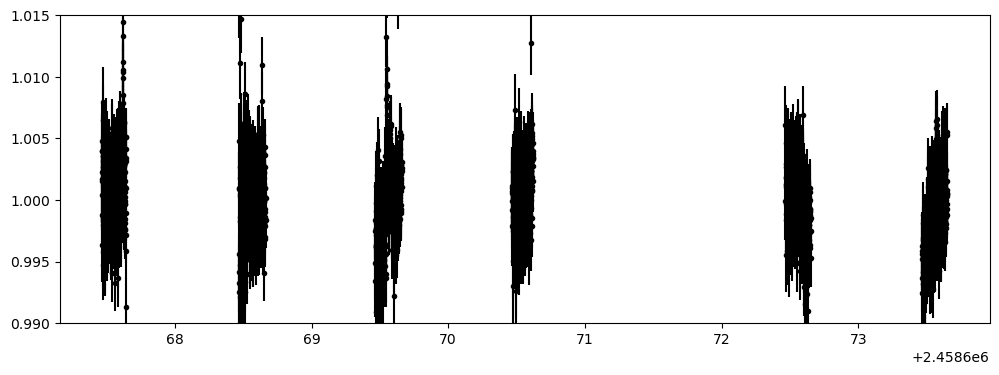

In [30]:
test_case = False
pre_bin = False

if test_case:
    t = list(np.linspace(0.5,0.9,200))
    daylength = len(t)
    ndays = 6
    gap = 16/24.
    A = 0.005
    
    for d in range(1,ndays):
        t.extend(np.array(t[:daylength]) + d * (1 + gap))
    
    t = np.array(t)
    ferr = 1e-3 * np.ones(len(t))
    sinusoid_trend = A * np.sin(t)
    f = 1 + sinusoid_trend + (ferr * (np.random.randn(len(t))))
    f[22] = 1.01 # add a cosmic
    f[63] = 1.008 # add a cosmic
    f[50] = 0.0 # add a zero flux point

else:
    file_path = "/Users/fl386/Desktop/SPECULOOS_project/zooniverse/data"
    files = glob.glob(file_path+"/*")

    i = 90
    file_name = files[i]
    gaia_id = file_name.split("/")[-1].replace(".csv","")

    data = pd.read_csv(file_name)

    mask = (~np.isnan(data["diff_flux_use"])) & (~np.isnan(data["diff_error"])) & (data["diff_error"]>0)
    data = data[mask]
    data.reset_index(drop = True, inplace = True)

    t = data["bjd"].values
    f = data["diff_flux_use"].values
    ferr = data["diff_error"].values
    print(f"nr of measurements: {len(t)}")
    if pre_bin:
        #0.005*24.*60. = 7 minutes
        #some problem if 7 mins or greater (with smaller_binning, problem with units in astropy)
        blc = binning(t, f, bins=0.01, error=ferr, std=True)
        t,f,ferr = blc
        print(f"nr of measurements after binning: {len(t)}")


# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [31]:
targ = LightCurve(name = "test",
                  time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  metadata={'R_star':0.1*u.R_sun, 'M_star':0.1*u.M_sun})

In [32]:
targ_with_transit = targ.inject_transit(per=2.2*u.d, epoch=0.7 * u.d, inc=90 * u.degree, rp=0.6 * u.R_earth, ld=[0.3,0.3])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='Flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

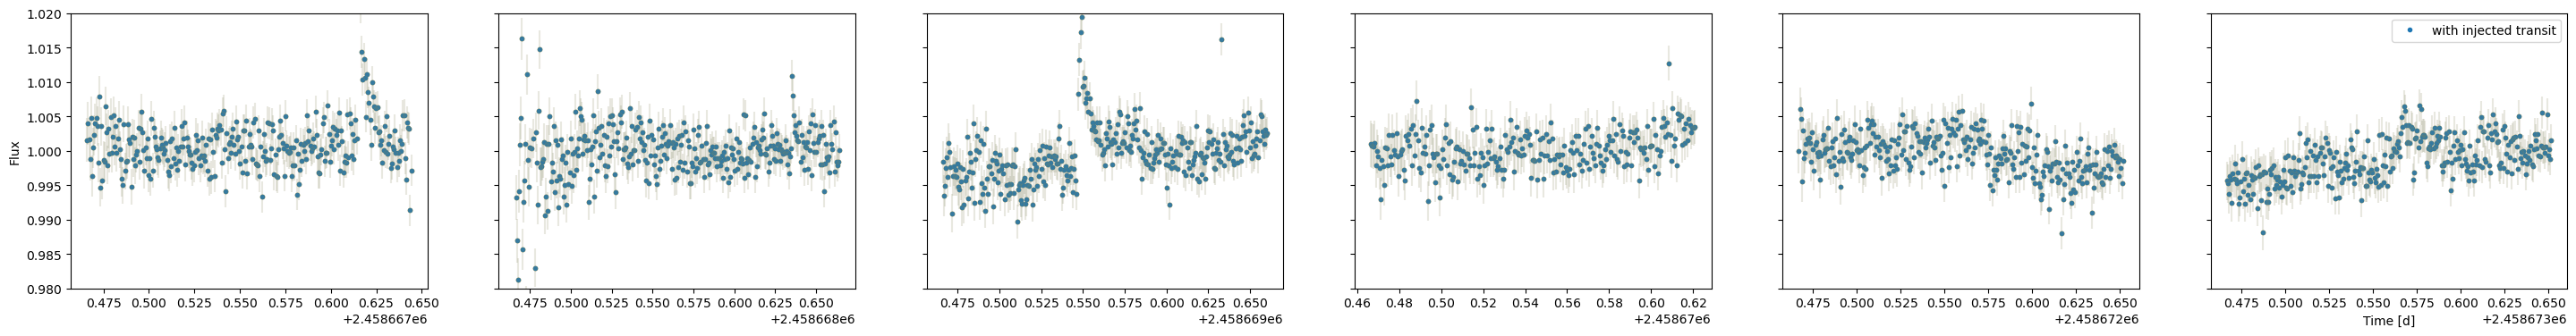

In [33]:
ax=targ.plot(color='orange')
targ_with_transit.plot(ax=ax, label="with injected transit")

In [34]:
targ_with_transit.metadata

{'name': 'test_inject',
 'target': 'test',
 'R_star': <Quantity 0.1 solRad>,
 'M_star': <Quantity 0.1 solMass>,
 'injected_planet': {'period': [<Quantity 2.2 d>],
  'epoch': [<Quantity 0.7 d>],
  'inc': [<Quantity 90. deg>],
  'rp': [<Quantity 0.6 earthRad>],
  'a': [<Quantity 3.30409793 solRad>],
  'a_Rs': [<Quantity 33.04097933>],
  'ld': [[0.3, 0.3]],
  'depth': [<Quantity 0.00302581>],
  'duration': [<Quantity 0.02236399 d>]}}

In [35]:
planets = targ_with_transit.create_lots_of_transit_params(nfake=100, 
                                                          minimum_planet_radius=0.5 * u.R_earth, maximum_planet_radius=3 * u.R_earth,
                                                          minimum_period=0.5 * u.d, maximum_period=1 * u.d,)

In [36]:
planets

,logP,phase,cosi,r_p,depth,duration,epoch,a,a_Rs,injected,...,rec_depth,rec_duration,rec_epoch,run,snr,target,r_s,m_s,teff,spt
0,-0.207292,0.317704,0.013827,1.276013,0.013685117553208693,0.015300,2.458668e+06,1.4209425089285486 solRad,14.209425089285485,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
1,-0.093857,0.757839,0.005733,2.143913,0.03863253018628523,0.018099,2.458668e+06,1.6912193892002134 solRad,16.912193892002133,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
2,-0.007885,0.826195,0.008268,0.978055,0.008040172743980304,0.017469,2.458668e+06,1.929808518917168 solRad,19.29808518917168,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
3,-0.104308,0.857864,0.006276,1.404668,0.01658388283675729,0.016920,2.458668e+06,1.6643027208744154 solRad,16.643027208744154,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
4,-0.209020,0.846783,0.002732,2.516143,0.05321195558912506,0.017096,2.458668e+06,1.4171774002397075 solRad,14.171774002397074,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-0.258147,0.258510,0.010740,2.692981,0.060954411626283296,0.016585,2.458668e+06,1.3142349428861657 solRad,13.142349428861657,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
96,-0.281950,0.541038,0.013694,2.904267,0.07089436047483812,0.016491,2.458668e+06,1.2670813083067027 solRad,12.670813083067026,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
97,-0.235768,0.059269,0.010779,2.403559,0.04855659626213678,0.016498,2.458668e+06,1.360167985261956 solRad,13.601679852619558,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None
98,-0.233063,0.563760,0.004600,0.557436,0.0026117299223428524,0.014312,2.458668e+06,1.3658277620490087 solRad,13.658277620490086,0.0,...,0.0,0.0,0.0,0.0,0.0,test_inject,0.1 solRad,0.1 solMass,None,None


In [37]:
# pool -> pool_bls
# nuance?
# nfakes = 1 before
# moved time_to_run & nfakes below import time
# rec_r_p = [x.to_value("R_earth") for x in (np.sqrt(planets_df['rec_depth']) * planets_df['r_s']).values]


In [38]:
import time

time_to_run = []
nfakes = [8]

for nfake in nfakes:
    start = time.time()
    lcs, lcs_clean, lcs_gp, lcs_bls, planets_df = targ.full_injection_recovery(nfake=nfake, 
                                                                               pool_bls=True, 
                                                                               minimum_planet_radius=0.25 * u.R_earth, 
                                                                               maximum_planet_radius=1 * u.R_earth,
                                                                               minimum_period=0.5 * u.d, 
                                                                               maximum_period=2 * u.d, 
                                                                               recovery_kw = {'condition_on_epoch':1 * u.hour},
                                                                               bls_kw = {"minimum_period":0.5, "maximum_period":10,
                                                                              'transit_durations':np.linspace(0.01, 0.1, 10),
                                                                              'return_all_transits':False,
                                                                              'plot':False},
                                                                               verbose=False)
    
    end = time.time()
    time_to_run.append(end - start)
    print(f"Time elapsed = {(end - start):.2f}s")

Pooling 8 injection-recoveries with 4 cores and kw={'chunksize': 1}.
Planets recovered: 50.0%
But not all of those planets transited during the observation window...
Observed Planets recovered: 66.7%
Time elapsed = 21.60s


In [39]:
time_to_run

[21.601019144058228]

Text(0.5, 0, 'Number of injected planets')

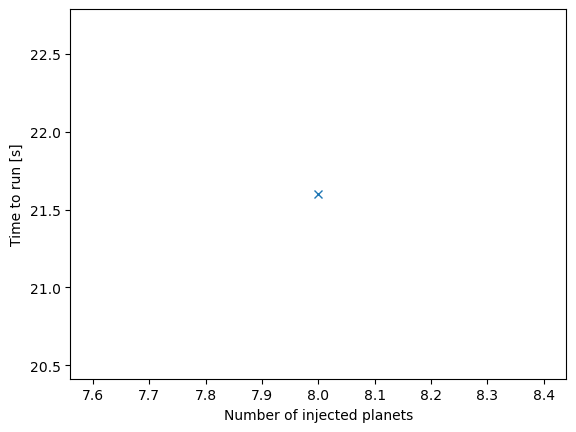

In [40]:
plt.plot(nfakes, time_to_run, 'x-')
plt.ylabel("Time to run [s]")
plt.xlabel("Number of injected planets")

In [41]:
nfakes, time_to_run,

([8], [21.601019144058228])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(0.98, 1.02)

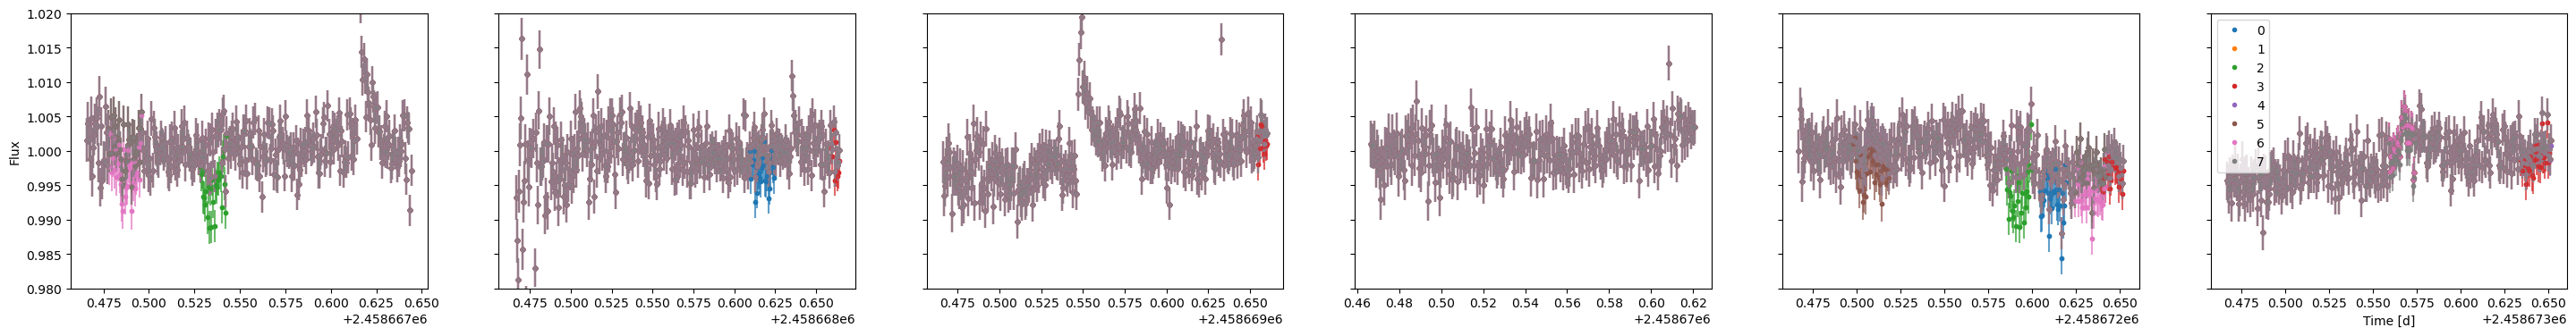

In [42]:
ax=targ.plot()
for i, lc in enumerate(lcs):
    lc.plot(ax=ax, ylims=[0.9,1.1], alpha_error=0.7, color=f"C{i}", label=i)
# plt.legend()
plt.ylim(0.98,1.02)

For whatever reason the pooling doesn't seem to work in Jupyter on my computer...?

In [60]:
# pool = mp.Pool(5)
# lcs = pool.starmap(inject_transit, [(targ, (10**logp) * u.d, phase * 10**logp * u.d, math.acos(cosi) * u.radian,
#                                               rp * u.R_earth, [0.1,0.1]) for
#                                              logp, phase, cosi, rp in zip(planets['logP'], planets['phase'], planets['cosi'],
#                                                                           planets['r_p'])])

In [43]:
planets_df['rec_depth'].head(1)

0    0.003515
Name: rec_depth, dtype: float64

In [44]:
planets_df['r_s'].head(1)

0    0.1 solRad
Name: r_s, dtype: object

In [45]:
planets_df['r_s'].loc[0]

'0.1 solRad'

In [46]:
planets_df['recovered']

0    1.0
1    0.0
2    1.0
3    1.0
4    0.0
5    0.0
6    1.0
7    0.0
Name: recovered, dtype: float64

In [47]:
#rec_r_p = [x.to_value("R_earth") for x in (np.sqrt(planets_df['rec_depth']) * planets_df['r_s']).values]

In [48]:
n_points_in_transit = planets_df['duration']/(7.5/(24*60))
lc_noise = 1e-3


In [42]:
rec_r_p = [x.to_value("R_earth") for x in (np.sqrt(planets_df['rec_depth']) * planets_df['r_s']).values]

for r_p, depth, rec, r_p_rec, snr, n in zip(planets_df['r_p'], planets_df['depth'],  planets_df['recovered'],rec_r_p,  planets_df['snr'], n_points_in_transit):
    if rec == 1.0:
        color = "orange"
    else:
        color = "C0"
    if r_p_rec == 0.0:
        r_p_rec = r_p
        snr = depth * np.sqrt(n)/lc_noise
    plt.plot([r_p,r_p_rec], [depth * np.sqrt(n)/lc_noise, snr], 'x-', color=color, alpha=0.6)
    if rec == 1.0:
        plt.plot([r_p_rec], [snr], 'x', color='darkred', alpha=0.5)
plt.ylabel("SNR")
plt.xlabel("Planet Radius [R_earth]")
# plot_transitparams(results[4]['r_p'], results[4]['depth'] * np.sqrt(n_points_in_transit)/lc_noise, results[4]['recovered'], xlabel="Radius", ylabel="SNR", zlabel="Detected?", ylims=[], yscale='uniform',
#                        xscale='uniform', add_points={}, svname="")

TypeError: can't multiply sequence by non-int of type 'float'

Print recovery stats:

In [49]:
print(f"Planets recovered: {100 * len(planets_df.loc[planets_df['recovered'] == 1.0]) /  len(planets_df['recovered'])}%")
print("But not all of those planets transited during the observation window...")
print(f"""Observed Planets recovered: {100 * len(planets_df.loc[(planets_df['recovered'] == 1.0) & 
            (planets_df['observed'] == 1.0)]) /  len(planets_df['recovered'][planets_df['observed']==1.0])}%""")

Planets recovered: 50.0%
But not all of those planets transited during the observation window...
Observed Planets recovered: 66.66666666666667%


Plot only the planets which were observed:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


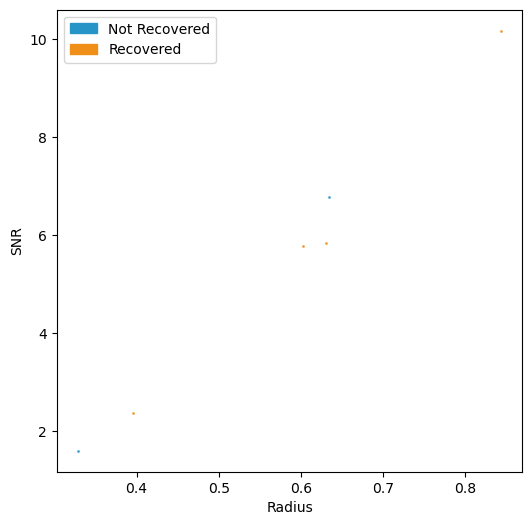

In [50]:
plot_transitparams(x=planets_df['r_p'][planets_df['observed'] == 1.0], 
                   y=planets_df['depth'][planets_df['observed'] == 1.0] * np.sqrt(n_points_in_transit[planets_df['observed'] == 1.0])/lc_noise, 
                   z=planets_df['recovered'][planets_df['observed'] == 1.0], 
                   xlabel="Radius", 
                   ylabel="SNR", 
                   zlabel="Detected?", 
                   ylims=[], 
                   yscale='uniform',
                   xscale='uniform', 
                   add_points={},
                   svname="")